## 1.1 — Modeling Objective

**What:** Xây HOG + Logistic Regression cho digit 0–9 robust với handwriting variation.

**Why:** Framing một model lifecycle, không phải comparison project.

**How:** Classifier bắt buộc LR; robustness targets translation/rotation/scale.

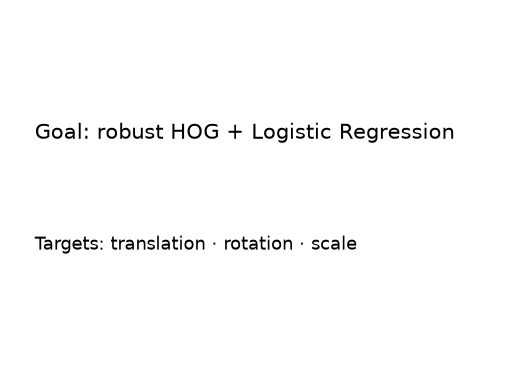

In [1]:
from pathlib import Path
from time import perf_counter
import json,os,numpy as np,matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog
from skimage.transform import resize,rotate
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,recall_score
ROOT=Path.cwd().parents[1] if Path.cwd().name=="Modeling" else Path.cwd(); VECTORS=ROOT/"Model"/"Dataset"/"Split data"/"Vectors"
plt.axis("off"); plt.text(.05,.65,"Goal: robust HOG + Logistic Regression",fontsize=15); plt.text(.05,.35,"Targets: translation · rotation · scale",fontsize=13); plt.show()

## 1.2 — Final Modeling Pipeline

**What:** Chốt một inference pipeline duy nhất.

**Why:** Giữ narrative tập trung vào selected model.

**How:** Training thêm augmentation trước HOG; inference không augment.

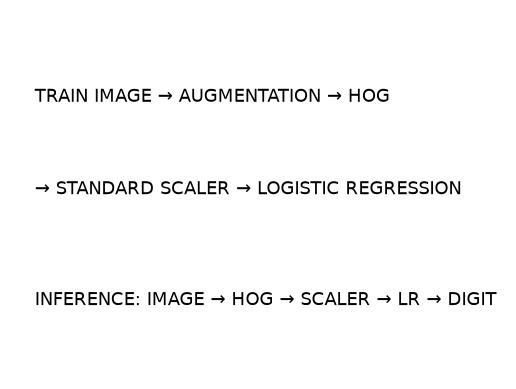

In [2]:
plt.axis("off"); plt.text(.05,.75,"TRAIN IMAGE → AUGMENTATION → HOG",fontsize=13); plt.text(.05,.5,"→ STANDARD SCALER → LOGISTIC REGRESSION",fontsize=13); plt.text(.05,.2,"INFERENCE: IMAGE → HOG → SCALER → LR → DIGIT",fontsize=13); plt.show()

## 1.3 — Experimental Data Contract

**What:** Phân vai Train, Validation và locked Test.

**Why:** Ngăn leakage và Test-driven decisions.

**How:** Train fit/augment; Validation tune/select; Test chỉ mở sau freeze.

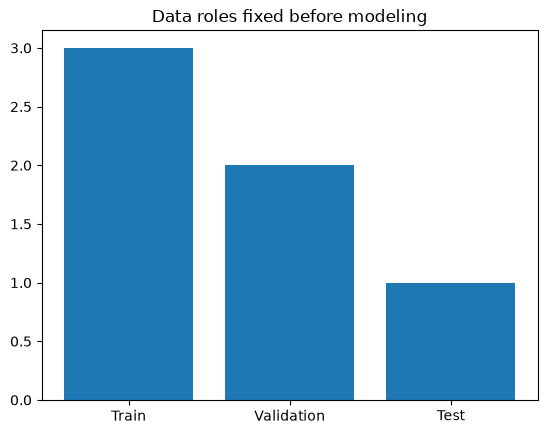

In [3]:
roles={"Train":"fit + augmentation","Validation":"tune + robustness","Test":"locked final evidence"}; plt.bar(list(roles),[3,2,1]); plt.title("Data roles fixed before modeling"); plt.show()

## 1.4 — Model Selection Criteria

**What:** Định nghĩa metric/rule trước search.

**Why:** Tránh chọn rule theo kết quả.

**How:** Primary Macro F1, secondary Accuracy; clean tolerance 0.003; maximize worst robustness.

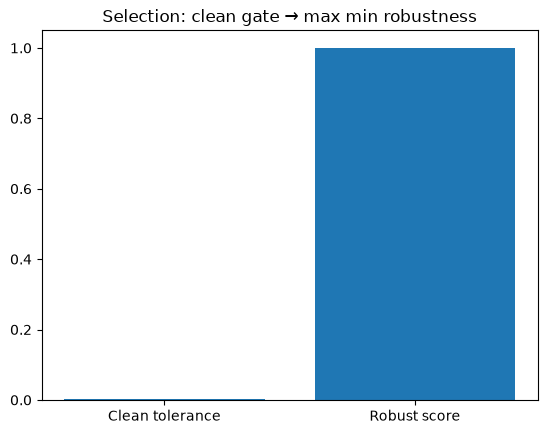

In [4]:
CLEAN_TOLERANCE=.003
def candidate_rank(r): return (r["robust_score"],r["clean_f1"],r["accuracy"])
plt.bar(["Clean tolerance","Robust score"],[CLEAN_TOLERANCE,1]); plt.title("Selection: clean gate → max min robustness"); plt.show()

## 2.1 — Load Development Data

**What:** Nạp 49k development samples và validate contract.

**Why:** Bắt sai shape/dtype/range trước modeling.

**How:** mmap read-only; transforms canonicalize writable input later.

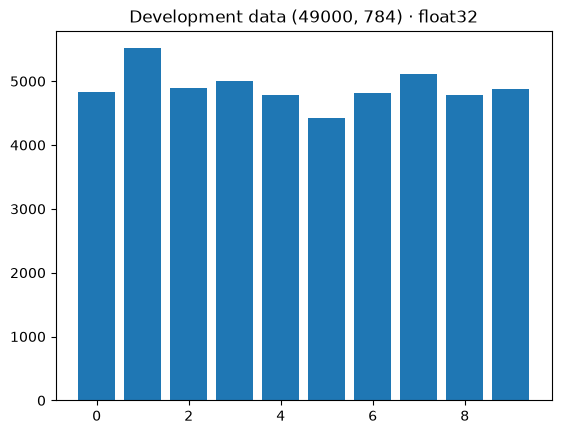

In [5]:
X_all=np.load(VECTORS/"Train"/"X_train_fe.npy",mmap_mode="r"); y_all=np.load(VECTORS/"Train"/"y_train.npy"); assert X_all.shape==(49000,784) and X_all.dtype==np.float32 and y_all.shape==(49000,) and X_all.min()>=0 and X_all.max()<=1
plt.bar(range(10),np.bincount(y_all)); plt.title(f"Development data {X_all.shape} · {X_all.dtype}"); plt.show()

## 2.2 — Train / Validation Split

**What:** Tạo stratified 80/20 split.

**Why:** Validation độc lập với fitting.

**How:** random_state=42.

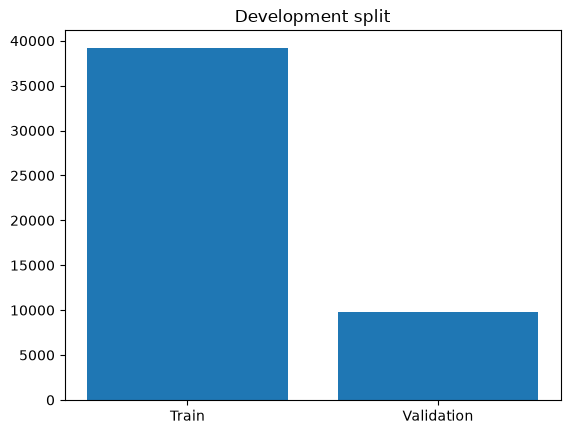

In [6]:
tr_idx,va_idx=train_test_split(np.arange(len(y_all)),test_size=.2,stratify=y_all,random_state=42); X_train=np.asarray(X_all[tr_idx]); y_train=y_all[tr_idx]; X_val=np.asarray(X_all[va_idx]); y_val=y_all[va_idx]
plt.bar(["Train","Validation"],[len(y_train),len(y_val)]); plt.title("Development split"); plt.show()

## 2.3 — Split Integrity Check

**What:** So class proportions Train/Validation.

**Why:** Xác nhận stratification.

**How:** Plot chênh lệch proportion theo digit.

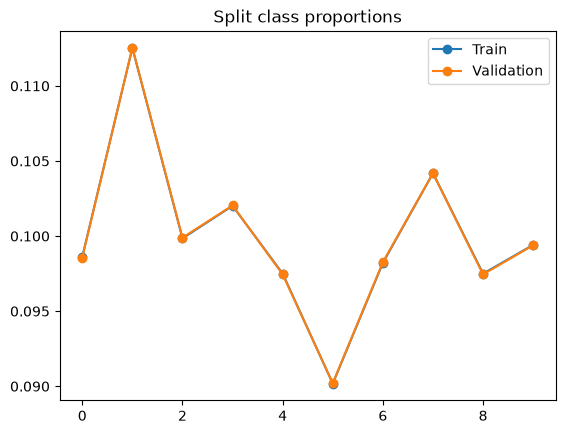

In [7]:
train_prop=np.bincount(y_train,minlength=10)/len(y_train); val_prop=np.bincount(y_val,minlength=10)/len(y_val); plt.plot(train_prop,"o-",label="Train"); plt.plot(val_prop,"o-",label="Validation"); plt.legend(); plt.title("Split class proportions"); plt.show()

## 2.4 — Locked Test Contract

**What:** Định nghĩa loader nhưng chưa gọi.

**Why:** Test không tham gia development.

**How:** Call duy nhất tại Block 8.3.

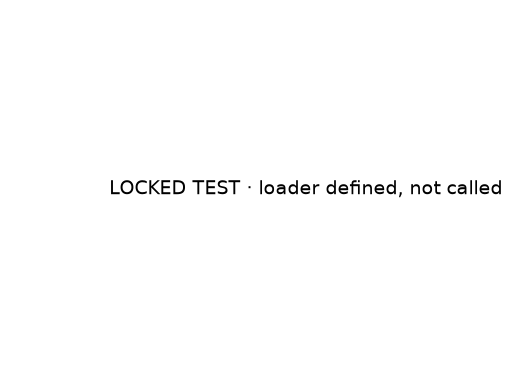

In [8]:
def load_locked_test(): return np.load(VECTORS/"Test"/"X_test.npy",mmap_mode="r"),np.load(VECTORS/"Test"/"y_test.npy")
plt.axis("off"); plt.text(.2,.5,"LOCKED TEST · loader defined, not called",fontsize=14); plt.show()

## 3.1 — Reference Benchmark: Raw Logistic Regression

**What:** Fit Raw 784 benchmark ngắn.

**Why:** Chỉ chứng minh lý do dùng HOG.

**How:** Không tune/augment/package Raw trong notebook này.

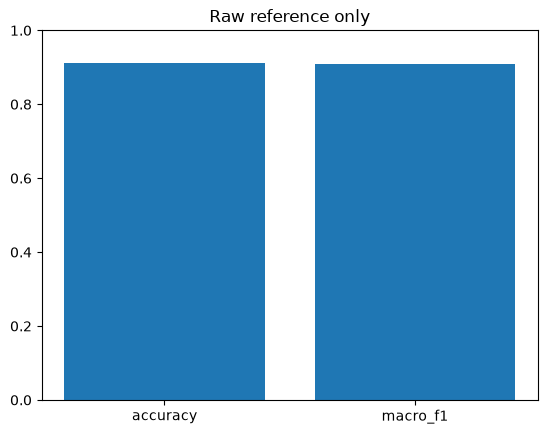

In [9]:
raw_reference=Pipeline([("scaler",StandardScaler()),("lr",LogisticRegression(C=1,solver="lbfgs",max_iter=500))]).fit(X_train,y_train)  # USER-RUN
raw_pred=raw_reference.predict(X_val); raw_reference_metrics={"accuracy":accuracy_score(y_val,raw_pred),"macro_f1":f1_score(y_val,raw_pred,average="macro")}; plt.bar(list(raw_reference_metrics),list(raw_reference_metrics.values())); plt.ylim(0,1); plt.title("Raw reference only"); plt.show()

## 3.2 — HOG Feature Configuration

**What:** Định nghĩa BASE_HOG.

**Why:** Chuyển pixels thành local gradient representation.

**How:** 9 orientations, 4×4 cell, 2×2 block, L2-Hys.

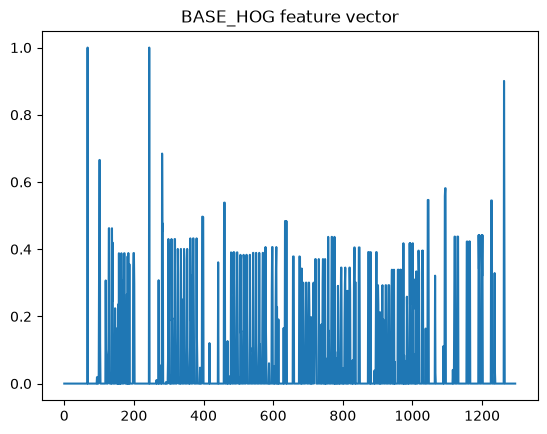

In [10]:
BASE_HOG={"orientations":9,"pixels_per_cell":(4,4),"cells_per_block":(2,2),"block_norm":"L2-Hys"}
def hog_one(flat,params=BASE_HOG): return hog(np.asarray(flat).reshape(28,28),feature_vector=True,**params)
plt.plot(hog_one(X_train[0])); plt.title("BASE_HOG feature vector"); plt.show()

## 3.3 — HOG Feature Extraction

**What:** Extract Train/Validation HOG.

**Why:** Cùng feature contract cho fit/evaluate.

**How:** Canonical helper trả float32.

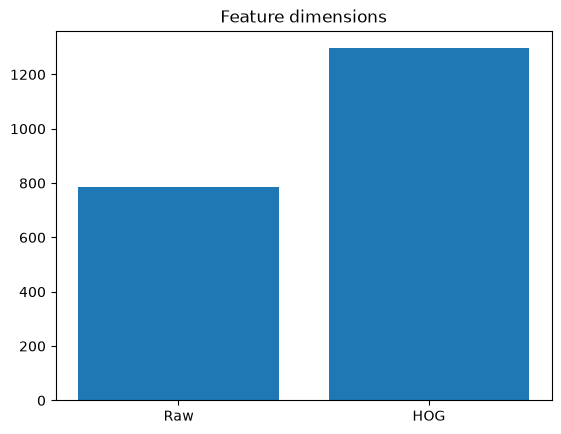

In [11]:
def extract_hog(X,params=BASE_HOG): return np.asarray([hog_one(row,params) for row in X],np.float32)
X_train_hog=extract_hog(X_train); X_val_hog=extract_hog(X_val); assert X_train_hog.shape[1]==X_val_hog.shape[1]
plt.bar(["Raw","HOG"],[784,X_train_hog.shape[1]]); plt.title("Feature dimensions"); plt.show()

## 3.4 — Feature Scaling

**What:** Fit scaler chỉ trên Train HOG.

**Why:** Tránh leakage và chuẩn hóa LR regularization.

**How:** Validation chỉ transform.

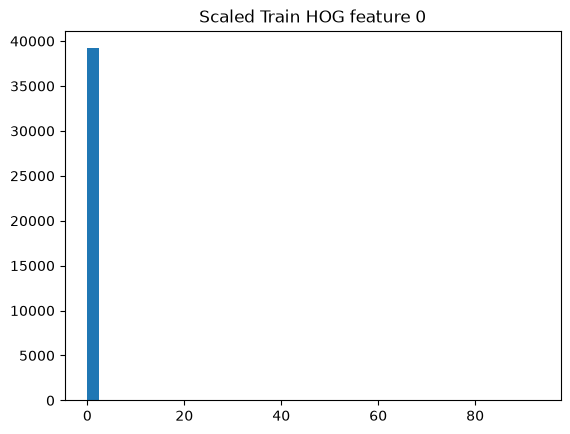

In [12]:
baseline_scaler=StandardScaler(); X_train_hog_s=baseline_scaler.fit_transform(X_train_hog); X_val_hog_s=baseline_scaler.transform(X_val_hog)
plt.hist(X_train_hog_s[:,0],bins=40); plt.title("Scaled Train HOG feature 0"); plt.show()

## 3.5 — Initial Logistic Regression Training

**What:** Fit baseline_model với C=1.

**Why:** Tạo model ban đầu để diagnosis.

**How:** Train-subset only.

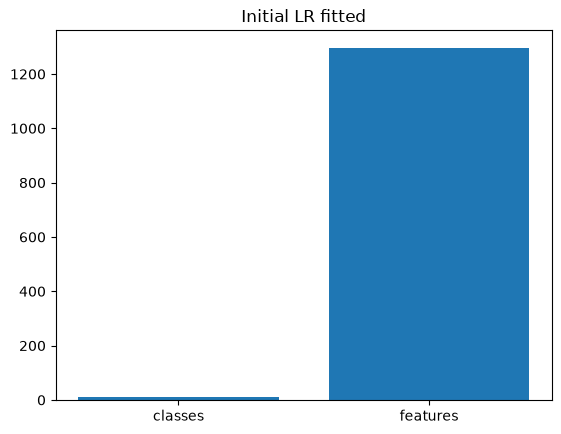

In [13]:
baseline_model=LogisticRegression(C=1,solver="lbfgs",max_iter=500).fit(X_train_hog_s,y_train)  # USER-RUN
plt.bar(["classes","features"],[len(baseline_model.classes_),baseline_model.coef_.shape[1]]); plt.title("Initial LR fitted"); plt.show()

## 3.6 — Initial Model Performance

**What:** Đo Train/Validation Accuracy và Macro F1.

**Why:** Cung cấp evidence cho diagnosis.

**How:** Không dùng Test.

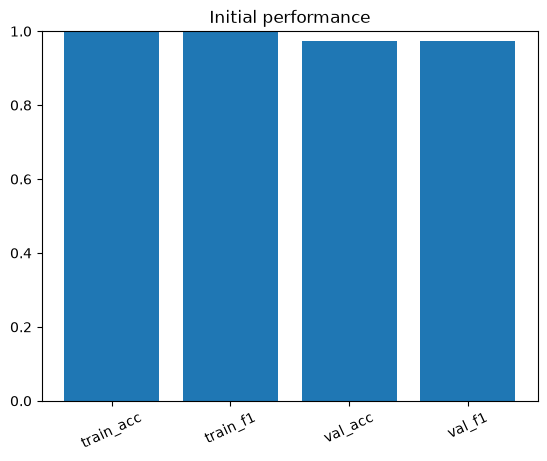

In [14]:
baseline_train_pred=baseline_model.predict(X_train_hog_s); baseline_val_pred=baseline_model.predict(X_val_hog_s); initial_metrics={"train_acc":accuracy_score(y_train,baseline_train_pred),"train_f1":f1_score(y_train,baseline_train_pred,average="macro"),"val_acc":accuracy_score(y_val,baseline_val_pred),"val_f1":f1_score(y_val,baseline_val_pred,average="macro")}; plt.bar(list(initial_metrics),list(initial_metrics.values())); plt.ylim(0,1); plt.xticks(rotation=25); plt.title("Initial performance"); plt.show()

## 4.1 — Generalization Gap

**What:** Tính Train–Validation gap.

**Why:** Phân biệt overfit nhẹ với distribution shift.

**How:** Gap thresholds được report, không tự gán nguyên nhân.

{'accuracy_gap': 0.0267857142857143, 'f1_gap': 0.026978579986833062}


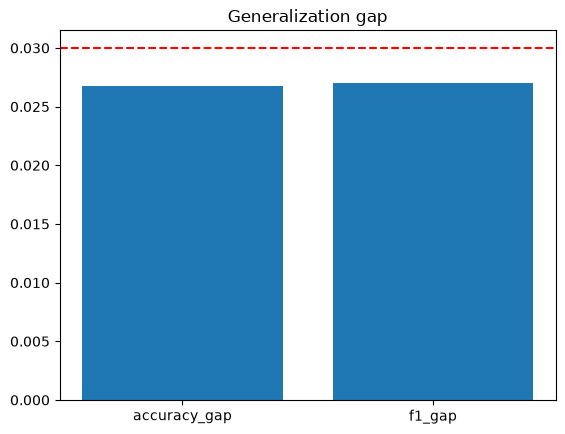

In [15]:
gaps={"accuracy_gap":initial_metrics["train_acc"]-initial_metrics["val_acc"],"f1_gap":initial_metrics["train_f1"]-initial_metrics["val_f1"]}; print(gaps); plt.bar(list(gaps),list(gaps.values())); plt.axhline(.03,color="red",ls="--"); plt.title("Generalization gap"); plt.show()

## 4.2 — Confusion Matrix

**What:** Tìm top confusion pairs.

**Why:** Xác định lỗi class-to-class cụ thể.

**How:** Bỏ diagonal rồi lấy top 8 counts.

[(3, 5, 15), (9, 4, 11), (4, 9, 10), (3, 2, 9), (5, 3, 9), (9, 7, 8), (7, 4, 8), (5, 9, 7)]


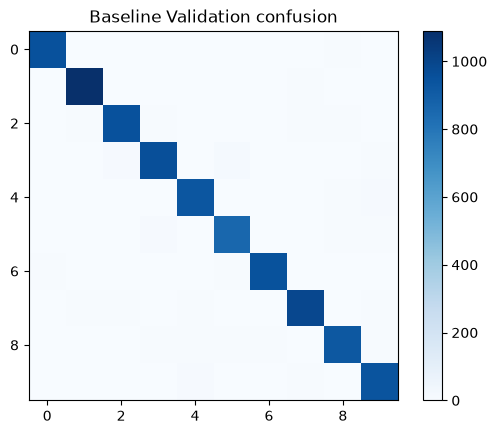

In [16]:
baseline_cm=confusion_matrix(y_val,baseline_val_pred); off=baseline_cm.copy(); np.fill_diagonal(off,0); top=np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1][:8],off.shape))[0]; top_pairs=[(int(a),int(b),int(off[a,b])) for a,b in top]; print(top_pairs); plt.imshow(baseline_cm,cmap="Blues"); plt.colorbar(); plt.title("Baseline Validation confusion"); plt.show()

## 4.3 — Per-Class Analysis

**What:** Report precision/recall/F1 từng digit, nhấn 1/7/9.

**Why:** Overall metric có thể che critical classes.

**How:** Classification report trên clean Validation.

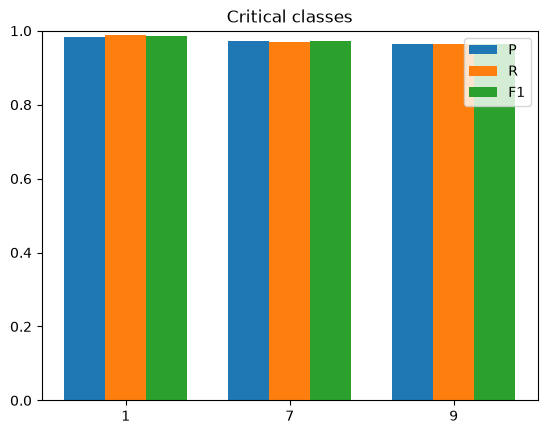

In [17]:
baseline_report=classification_report(y_val,baseline_val_pred,output_dict=True); focus=[1,7,9]; x=np.arange(3); plt.bar(x-.25,[baseline_report[str(d)]["precision"] for d in focus],.25,label="P"); plt.bar(x,[baseline_report[str(d)]["recall"] for d in focus],.25,label="R"); plt.bar(x+.25,[baseline_report[str(d)]["f1-score"] for d in focus],.25,label="F1"); plt.xticks(x,focus); plt.ylim(0,1); plt.legend(); plt.title("Critical classes"); plt.show()

## 4.4 — Translation Stress Test

**What:** Đo horizontal/vertical ±1–4.

**Why:** Xác định shift magnitude bắt đầu collapse.

**How:** Zero-fill, no wrap; Validation inference only.

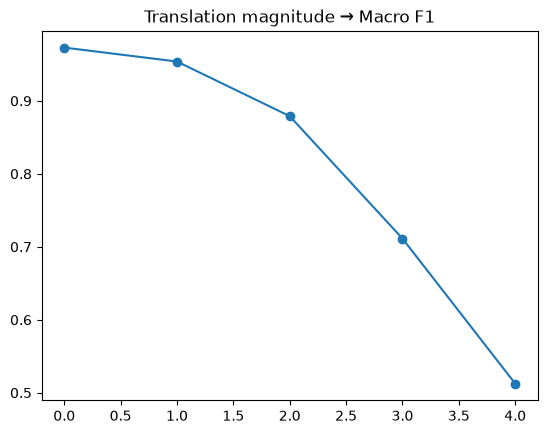

In [18]:
def shift_images(X,dx=0,dy=0):
 imgs=np.asarray(X).reshape(-1,28,28); out=np.zeros_like(imgs); yd=slice(max(0,dy),min(28,28+dy)); xd=slice(max(0,dx),min(28,28+dx)); out[:,yd,xd]=imgs[:,slice(max(0,-dy),min(28,28-dy)),slice(max(0,-dx),min(28,28-dx))]; return out.reshape(-1,784)
def predict_hog(model,scaler,X,params=BASE_HOG): return model.predict(scaler.transform(extract_hog(X,params)))
def score_pred(y,p): return {"accuracy":accuracy_score(y,p),"f1":f1_score(y,p,average="macro"),"recall":recall_score(y,p,labels=[1,7,9],average=None)}
translation_scores={}
for s in range(5):
 preds=[predict_hog(baseline_model,baseline_scaler,shift_images(X_val,dx,dy)) for dx,dy in ([(0,0)] if s==0 else [(s,0),(-s,0),(0,s),(0,-s)])]; translation_scores[s]={"accuracy":np.mean([accuracy_score(y_val,p) for p in preds]),"f1":np.mean([f1_score(y_val,p,average="macro") for p in preds])}
plt.plot(list(translation_scores),[v["f1"] for v in translation_scores.values()],"o-"); plt.title("Translation magnitude → Macro F1"); plt.show()

## 4.5 — Rotation Stress Test

**What:** Đo ±5/10/15°.

**Why:** Kiểm tra orientation sensitivity.

**How:** Writable float32 boundary trước skimage.rotate.

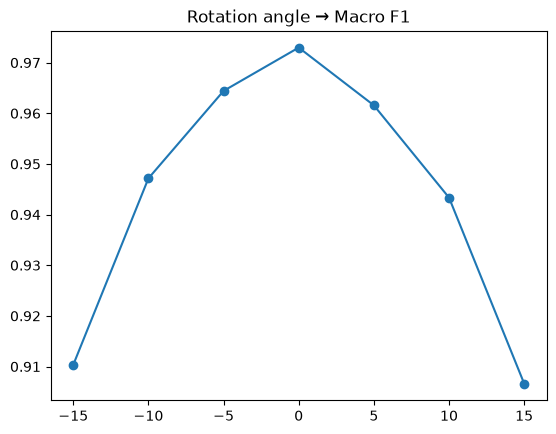

In [19]:
def rotate_images(X,angle): return np.asarray([rotate(np.array(x,dtype=np.float32,copy=True,order="C").reshape(28,28),angle,resize=False,preserve_range=True,mode="constant").reshape(-1) for x in X],np.float32)
rotation_scores={a:score_pred(y_val,predict_hog(baseline_model,baseline_scaler,rotate_images(X_val,a))) for a in [-15,-10,-5,0,5,10,15]}; plt.plot(list(rotation_scores),[v["f1"] for v in rotation_scores.values()],"o-"); plt.title("Rotation angle → Macro F1"); plt.show()

## 4.6 — Scale Stress Test

**What:** Đo 0.75/0.85/1/1.15/1.25.

**Why:** Kiểm tra digit size sensitivity.

**How:** Resize rồi center canvas 28×28; writable boundary.

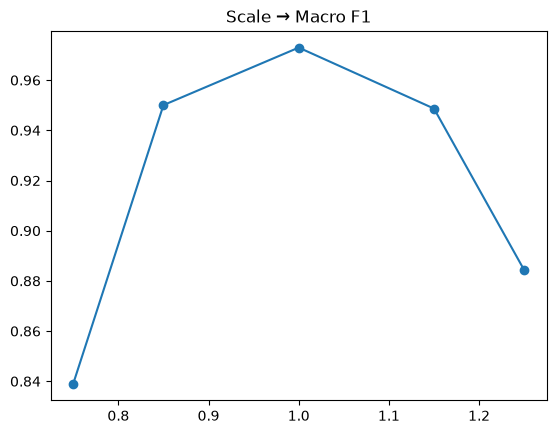

In [20]:
def scale_image(flat,factor):
 image=np.array(flat,dtype=np.float32,copy=True,order="C").reshape(28,28); size=max(1,round(28*factor)); z=resize(image,(size,size),preserve_range=True,anti_aliasing=True); out=np.zeros((28,28),np.float32)
 if size<=28: q=(28-size)//2; out[q:q+size,q:q+size]=z
 else: q=(size-28)//2; out=z[q:q+28,q:q+28]
 return out.reshape(-1)
def scale_images(X,factor): return np.asarray([scale_image(x,factor) for x in X],np.float32)
scale_scores={s:score_pred(y_val,predict_hog(baseline_model,baseline_scaler,scale_images(X_val,s))) for s in [.75,.85,1,1.15,1.25]}; plt.plot(list(scale_scores),[v["f1"] for v in scale_scores.values()],"o-"); plt.title("Scale → Macro F1"); plt.show()

## 4.7 — Class-Level Robustness

**What:** Đo recall 1/7/9 theo transforms chính.

**Why:** Phát hiện weakness bị overall F1 che.

**How:** Clean, shift ±2/±3, rotation ±10, scale .85.

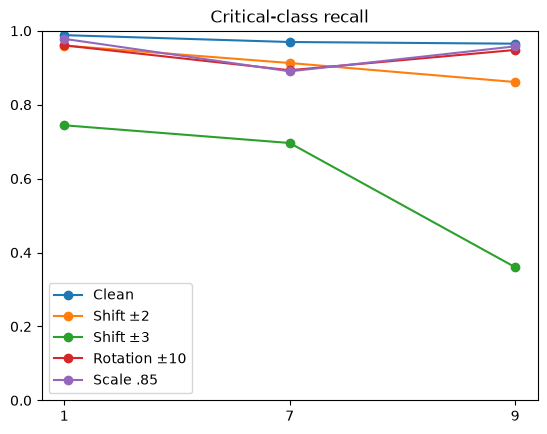

In [21]:
critical={"Clean":score_pred(y_val,baseline_val_pred)["recall"],"Shift ±2":np.mean([score_pred(y_val,predict_hog(baseline_model,baseline_scaler,shift_images(X_val,d,0)))["recall"] for d in [-2,2]],0),"Shift ±3":np.mean([score_pred(y_val,predict_hog(baseline_model,baseline_scaler,shift_images(X_val,0,d)))["recall"] for d in [-3,3]],0),"Rotation ±10":np.mean([rotation_scores[d]["recall"] for d in [-10,10]],0),"Scale .85":scale_scores[.85]["recall"]}; x=np.arange(3); [plt.plot(x,v,"o-",label=k) for k,v in critical.items()]; plt.xticks(x,[1,7,9]); plt.ylim(0,1); plt.legend(); plt.title("Critical-class recall"); plt.show()

## 4.8 — Diagnosis & Modeling Decision

**What:** Tóm tắt gap và worst robustness.

**Why:** Nối evidence tới intervention.

**How:** Decision cố định: training-only augmentation.

Decision: add training-only augmentation {'f1_gap': 0.026978579986833062, 'worst_shift': np.float64(0.5125110252327189), 'worst_rotation': 0.9066349743941787, 'worst_scale': 0.8390763020088979}


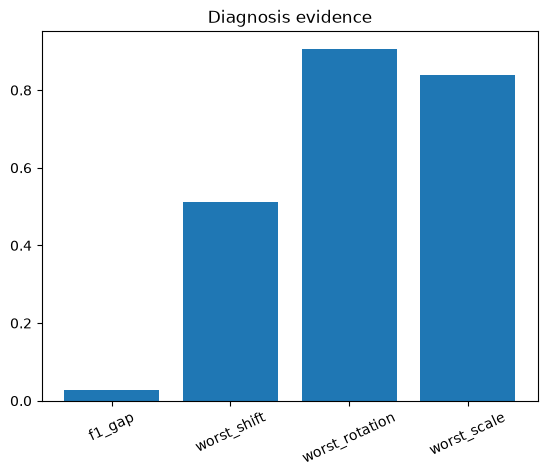

In [22]:
diagnosis={"f1_gap":gaps["f1_gap"],"worst_shift":min(v["f1"] for v in translation_scores.values()),"worst_rotation":min(v["f1"] for v in rotation_scores.values()),"worst_scale":min(v["f1"] for v in scale_scores.values())}; print("Decision: add training-only augmentation",diagnosis); plt.bar(list(diagnosis),list(diagnosis.values())); plt.xticks(rotation=25); plt.title("Diagnosis evidence"); plt.show()

## 5.1 — Augmentation Strategy

**What:** Freeze factor/translation/rotation/scale config.

**Why:** Function must consume config, không hard-code.

**How:** Factor 3 = original + translated + rotate-scale.

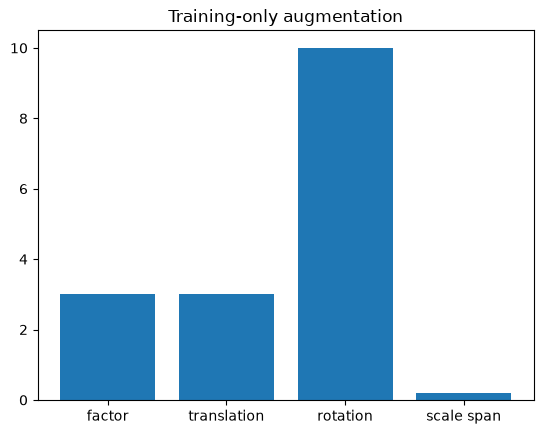

In [23]:
AUGMENTATION={"factor":3,"translation":3,"rotation":10,"scale":[.9,1.1],"random_state":42}; plt.bar(["factor","translation","rotation","scale span"],[AUGMENTATION["factor"],AUGMENTATION["translation"],AUGMENTATION["rotation"],AUGMENTATION["scale"][1]-AUGMENTATION["scale"][0]]); plt.title("Training-only augmentation"); plt.show()

## 5.2 — Augmentation Implementation

**What:** Tạo variants theo config.

**Why:** Mở rộng training distribution, không đụng Validation/Test.

**How:** Factor currently 3; reject unsupported factor explicitly.

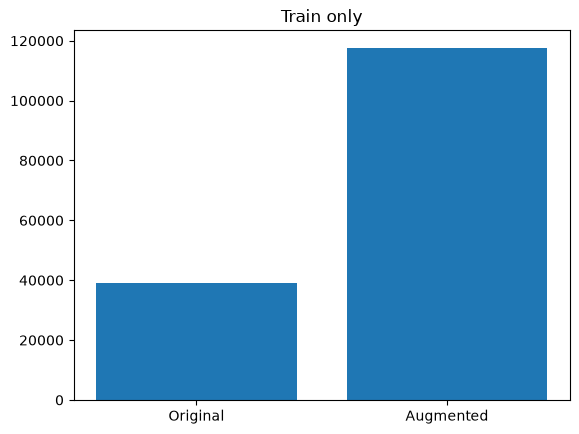

In [24]:
def augment_training(X,y,config=AUGMENTATION):
 if config["factor"]!=3: raise ValueError("factor must be 3: original + translation + rotate-scale")
 X=np.array(X,dtype=np.float32,copy=True,order="C"); rng=np.random.default_rng(config["random_state"]); t=[]; a=[]; limit=int(config["translation"]); lo,hi=config["scale"]
 for row in X:
  t.append(shift_images(row.reshape(1,-1),int(rng.integers(-limit,limit+1)),int(rng.integers(-limit,limit+1)))[0]); r=rotate_images(row.reshape(1,-1),float(rng.uniform(-config["rotation"],config["rotation"])))[0]; a.append(scale_image(r,float(rng.uniform(lo,hi))))
 return np.concatenate([X,np.asarray(t,np.float32),np.asarray(a,np.float32)]),np.tile(y,config["factor"])
X_train_aug,y_train_aug=augment_training(X_train,y_train)  # USER-RUN
plt.bar(["Original","Augmented"],[len(X_train),len(X_train_aug)]); plt.title("Train only"); plt.show()

## 5.3 — Augmentation Sanity Check

**What:** Hiển thị original/translated/rotate-scale.

**Why:** Bắt semantic corruption bằng mắt.

**How:** Cùng sample index qua ba segments.

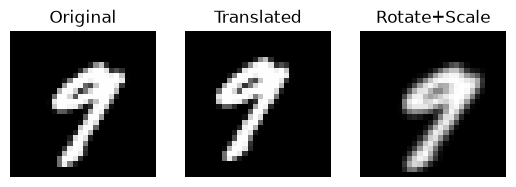

In [25]:
i=np.flatnonzero(y_train==9)[0]; fig,ax=plt.subplots(1,3); [a.imshow(X_train_aug[i+j*len(X_train)].reshape(28,28),cmap="gray") for j,a in enumerate(ax)]; [a.axis("off") for a in ax]; [a.set_title(t) for a,t in zip(ax,["Original","Translated","Rotate+Scale"])]; plt.show()

## 5.4 — Augmented HOG Extraction

**What:** Extract HOG sau augmentation.

**Why:** Spatial transforms phải xảy ra trên image.

**How:** BASE_HOG trước optimization.

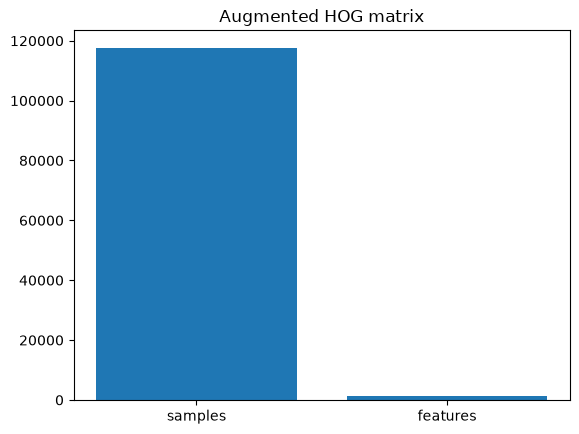

In [26]:
X_train_aug_hog=extract_hog(X_train_aug,BASE_HOG); augmented_scaler=StandardScaler(); X_train_aug_hog_s=augmented_scaler.fit_transform(X_train_aug_hog); X_val_aug_hog_s=augmented_scaler.transform(X_val_hog); plt.bar(["samples","features"],[X_train_aug_hog.shape[0],X_train_aug_hog.shape[1]]); plt.title("Augmented HOG matrix"); plt.show()

## 5.5 — Robust Model Training

**What:** Fit augmented_baseline_model với C=1.

**Why:** Đo augmentation effect trước joint tuning.

**How:** Same HOG/C as initial baseline.

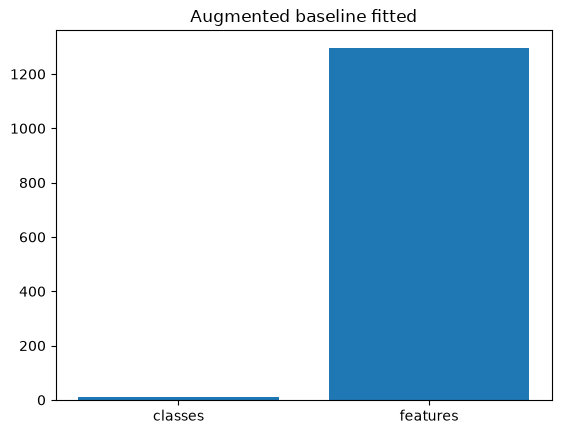

In [27]:
augmented_baseline_model=LogisticRegression(C=1,solver="lbfgs",max_iter=500).fit(X_train_aug_hog_s,y_train_aug)  # USER-RUN
plt.bar(["classes","features"],[10,augmented_baseline_model.coef_.shape[1]]); plt.title("Augmented baseline fitted"); plt.show()

## 5.6 — Augmentation Effect

**What:** So baseline HOG và augmented baseline đúng diagnosis metrics.

**Why:** Xác nhận intervention giải quyết vấn đề.

**How:** Clean/shift3/rotation10/scale.85 trên Validation.

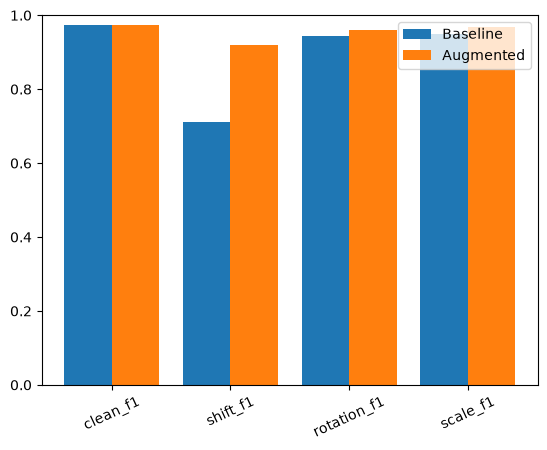

In [28]:
def candidate_metrics(model,scaler,params=BASE_HOG):
 clean=score_pred(y_val,predict_hog(model,scaler,X_val,params)); shift=np.mean([f1_score(y_val,predict_hog(model,scaler,shift_images(X_val,dx,dy),params),average="macro") for dx,dy in [(3,0),(-3,0),(0,3),(0,-3)]]); rot=np.mean([f1_score(y_val,predict_hog(model,scaler,rotate_images(X_val,a),params),average="macro") for a in [-10,10]]); scale=np.mean([f1_score(y_val,predict_hog(model,scaler,scale_images(X_val,s),params),average="macro") for s in [.85,1.15]]); return {"accuracy":clean["accuracy"],"clean_f1":clean["f1"],"shift_f1":shift,"rotation_f1":rot,"scale_f1":scale,"robust_score":min(clean["f1"],shift,rot,scale)}
baseline_effect=candidate_metrics(baseline_model,baseline_scaler); augmented_effect=candidate_metrics(augmented_baseline_model,augmented_scaler); keys=["clean_f1","shift_f1","rotation_f1","scale_f1"]; x=np.arange(4); plt.bar(x-.2,[baseline_effect[k] for k in keys],.4,label="Baseline"); plt.bar(x+.2,[augmented_effect[k] for k in keys],.4,label="Augmented"); plt.xticks(x,keys,rotation=25); plt.ylim(0,1); plt.legend(); plt.show()

## 6.1 — Search Space

**What:** Định nghĩa compact joint HOG × C space.

**Why:** Đủ đo interaction, không grid thừa.

**How:** 4 HOG configs × 5 C.

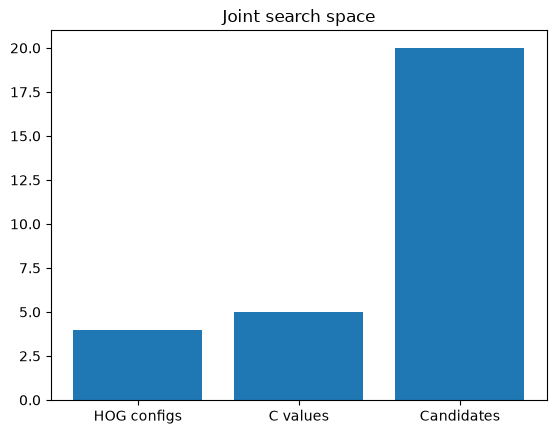

In [29]:
HOG_SPACE=[BASE_HOG,{**BASE_HOG,"orientations":12},{**BASE_HOG,"pixels_per_cell":(7,7)},{**BASE_HOG,"orientations":12,"pixels_per_cell":(7,7)}]; C_SPACE=[.01,.03,.1,.3,1]; plt.bar(["HOG configs","C values","Candidates"],[len(HOG_SPACE),len(C_SPACE),len(HOG_SPACE)*len(C_SPACE)]); plt.title("Joint search space"); plt.show()

## 6.2 — Joint HOG × C Search

**What:** Fit mọi C cho từng HOG config.

**Why:** Tìm interaction representation × regularization.

**How:** Reuse extracted/scaled matrices trong cùng HOG config.

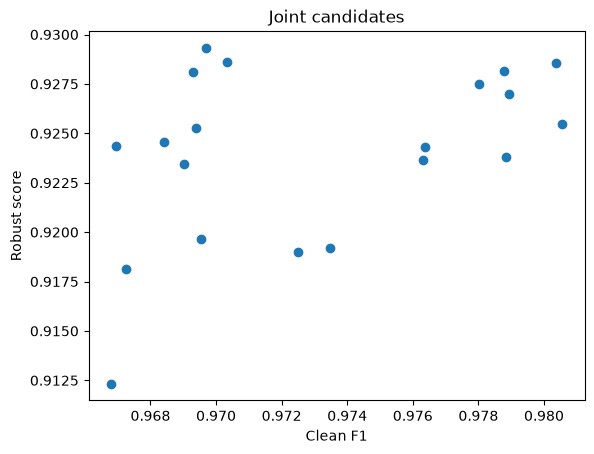

In [30]:
candidate_runs=[]
for params in HOG_SPACE:
 Xt=extract_hog(X_train_aug,params); Xv=extract_hog(X_val,params); scaler=StandardScaler(); Xt_s=scaler.fit_transform(Xt)
 for C in C_SPACE:
  model=LogisticRegression(C=C,solver="lbfgs",max_iter=500).fit(Xt_s,y_train_aug); metrics=candidate_metrics(model,scaler,params); candidate_runs.append({"hog":params,"C":C,"model":model,"scaler":scaler,**metrics})
plt.plot([r["clean_f1"] for r in candidate_runs],[r["robust_score"] for r in candidate_runs],"o"); plt.xlabel("Clean F1"); plt.ylabel("Robust score"); plt.title("Joint candidates"); plt.show()

## 6.3 — Candidate Evaluation

**What:** Lưu đầy đủ clean/shift/rotation/scale/robust score.

**Why:** Leaderboard auditable.

**How:** In compact rows không chứa model/scaler.

1 {'hog': {'orientations': 12, 'pixels_per_cell': (7, 7), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys'}, 'C': 0.3, 'clean_f1': 0.9696927535188289, 'shift_f1': np.float64(0.9293334035261362), 'rotation_f1': np.float64(0.9565611284291069), 'scale_f1': np.float64(0.9636077902301795), 'robust_score': np.float64(0.9293334035261362)}
2 {'hog': {'orientations': 12, 'pixels_per_cell': (7, 7), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys'}, 'C': 0.1, 'clean_f1': 0.9703188461280738, 'shift_f1': np.float64(0.9285969203310203), 'rotation_f1': np.float64(0.9575483664137325), 'scale_f1': np.float64(0.9642460105649738), 'robust_score': np.float64(0.9285969203310203)}
3 {'hog': {'orientations': 12, 'pixels_per_cell': (4, 4), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys'}, 'C': 0.03, 'clean_f1': 0.980357234734122, 'shift_f1': np.float64(0.9285615310675602), 'rotation_f1': np.float64(0.9673494597044754), 'scale_f1': np.float64(0.9741505760742424), 'robust_score': np.float64(0.92856153106756

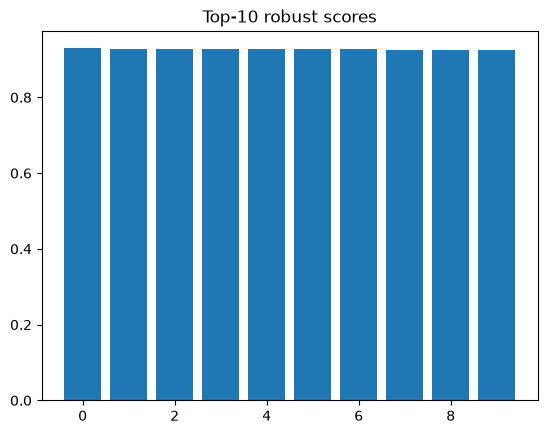

In [31]:
leaderboard=sorted(candidate_runs,key=candidate_rank,reverse=True); rows=[{"hog":r["hog"],"C":r["C"],**{k:r[k] for k in ["clean_f1","shift_f1","rotation_f1","scale_f1","robust_score"]}} for r in leaderboard]; [print(i+1,row) for i,row in enumerate(rows[:10])]; plt.bar(range(10),[r["robust_score"] for r in leaderboard[:10]]); plt.title("Top-10 robust scores"); plt.show()

## 6.4 — Candidate Selection

**What:** Áp dụng clean gate rồi maximize robust score.

**Why:** Tuân selection rule Heading 1.

**How:** Tolerance 0.003; Accuracy tie-break.

SELECTED {'hog': {'orientations': 12, 'pixels_per_cell': (4, 4), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys'}, 'C': 0.03, 'accuracy': 0.9804081632653061, 'clean_f1': 0.980357234734122, 'shift_f1': np.float64(0.9285615310675602), 'rotation_f1': np.float64(0.9673494597044754), 'scale_f1': np.float64(0.9741505760742424), 'robust_score': np.float64(0.9285615310675602)}


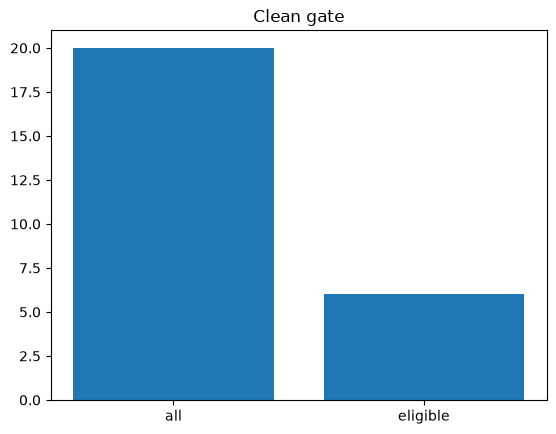

In [32]:
best_clean=max(r["clean_f1"] for r in candidate_runs); eligible=[r for r in candidate_runs if r["clean_f1"]>=best_clean-CLEAN_TOLERANCE]; selected_run=max(eligible,key=candidate_rank); print("SELECTED",{k:selected_run[k] for k in ["hog","C","accuracy","clean_f1","shift_f1","rotation_f1","scale_f1","robust_score"]}); plt.bar(["all","eligible"],[len(candidate_runs),len(eligible)]); plt.title("Clean gate"); plt.show()

## 7.1 — Selected Configuration

**What:** Report HOG/C/augmentation.

**Why:** Một config rõ ràng trước validation.

**How:** Không dùng Test.

{'orientations': 12, 'pixels_per_cell': (4, 4), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys'} 0.03 {'factor': 3, 'translation': 3, 'rotation': 10, 'scale': [0.9, 1.1], 'random_state': 42}


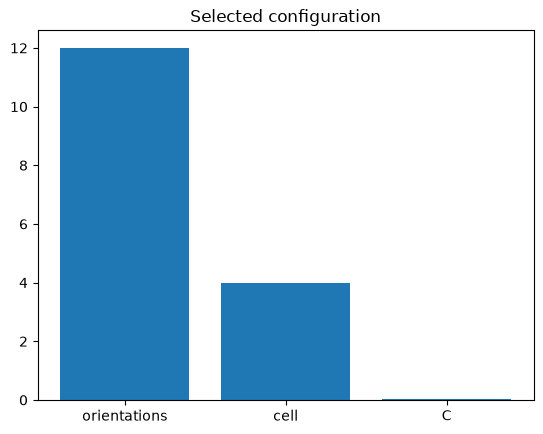

In [33]:
SELECTED_HOG=selected_run["hog"]; SELECTED_C=selected_run["C"]; print(SELECTED_HOG,SELECTED_C,AUGMENTATION); plt.bar(["orientations","cell","C"],[SELECTED_HOG["orientations"],SELECTED_HOG["pixels_per_cell"][0],SELECTED_C]); plt.title("Selected configuration"); plt.show()

## 7.2 — Clean Validation Performance

**What:** Report Accuracy/Macro F1/classification report.

**Why:** Xác nhận clean constraint.

**How:** Selected model on clean Validation.

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.99      0.98      0.99      1103
           2       0.98      0.97      0.98       979
           3       0.98      0.98      0.98      1000
           4       0.98      0.99      0.98       955
           5       0.99      0.98      0.98       884
           6       0.99      0.99      0.99       963
           7       0.98      0.98      0.98      1021
           8       0.96      0.97      0.97       955
           9       0.97      0.97      0.97       974

    accuracy                           0.98      9800
   macro avg       0.98      0.98      0.98      9800
weighted avg       0.98      0.98      0.98      9800



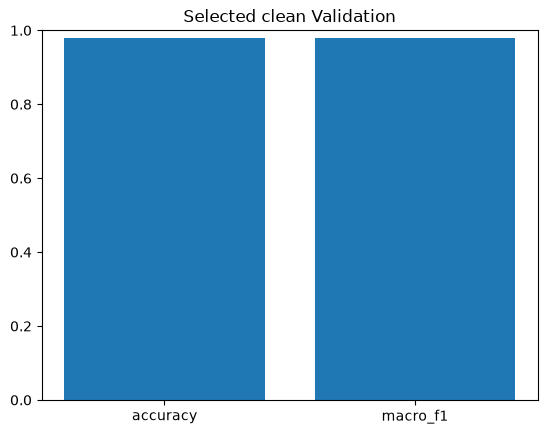

In [34]:
selected_pred=predict_hog(selected_run["model"],selected_run["scaler"],X_val,SELECTED_HOG); selected_report=classification_report(y_val,selected_pred,output_dict=True); selected_clean={"accuracy":accuracy_score(y_val,selected_pred),"macro_f1":f1_score(y_val,selected_pred,average="macro")}; print(classification_report(y_val,selected_pred)); plt.bar(list(selected_clean),list(selected_clean.values())); plt.ylim(0,1); plt.title("Selected clean Validation"); plt.show()

## 7.3 — Robustness Validation

**What:** Đo shift ±1/2/3, rotation ±5/10, scale .85/1.15.

**Why:** Xác nhận selected candidate trên target conditions.

**How:** Validation only.

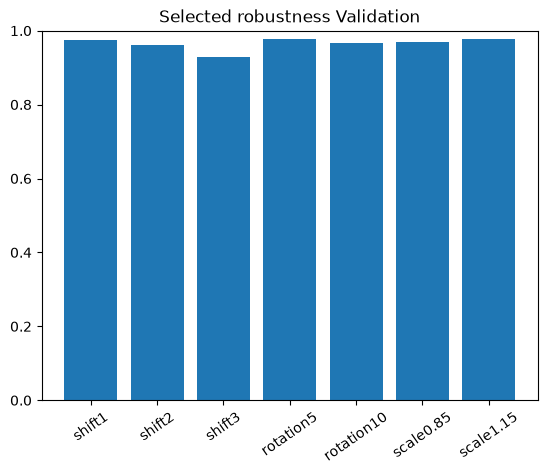

In [35]:
selected_robust={}
for s in [1,2,3]: selected_robust[f"shift{s}"]=np.mean([f1_score(y_val,predict_hog(selected_run["model"],selected_run["scaler"],shift_images(X_val,dx,dy),SELECTED_HOG),average="macro") for dx,dy in [(s,0),(-s,0),(0,s),(0,-s)]])
for a in [5,10]: selected_robust[f"rotation{a}"]=np.mean([f1_score(y_val,predict_hog(selected_run["model"],selected_run["scaler"],rotate_images(X_val,d),SELECTED_HOG),average="macro") for d in [-a,a]])
for s in [.85,1.15]: selected_robust[f"scale{s}"]=f1_score(y_val,predict_hog(selected_run["model"],selected_run["scaler"],scale_images(X_val,s),SELECTED_HOG),average="macro")
plt.bar(list(selected_robust),list(selected_robust.values())); plt.xticks(rotation=35); plt.ylim(0,1); plt.title("Selected robustness Validation"); plt.show()

## 7.4 — Critical Classes 1/7/9

**What:** So baseline và selected F1 critical classes.

**Why:** Comparison cuối phục vụ objective.

**How:** Clean Validation per-class F1.

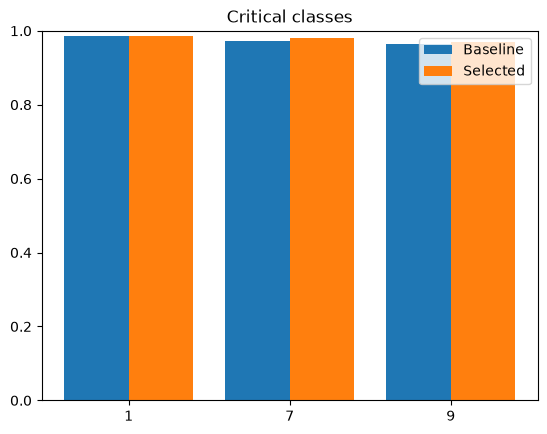

In [36]:
critical_baseline=[baseline_report[str(d)]["f1-score"] for d in focus]; critical_selected=[selected_report[str(d)]["f1-score"] for d in focus]; x=np.arange(3); plt.bar(x-.2,critical_baseline,.4,label="Baseline"); plt.bar(x+.2,critical_selected,.4,label="Selected"); plt.xticks(x,focus); plt.ylim(0,1); plt.legend(); plt.title("Critical classes"); plt.show()

## 7.5 — Accept / Reject Decision

**What:** Đưa ra deterministic lifecycle decision.

**Why:** Không freeze model không đạt constraints.

**How:** Accept nếu clean gate và robust score không kém augmented baseline.

ACCEPT


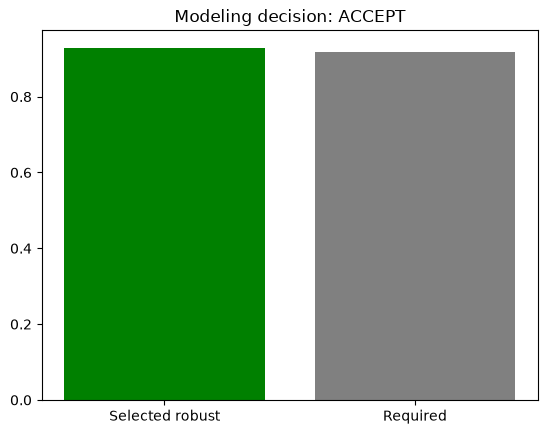

In [37]:
ACCEPTED=selected_run["clean_f1"]>=best_clean-CLEAN_TOLERANCE and selected_run["robust_score"]>=augmented_effect["robust_score"]; DECISION="ACCEPT" if ACCEPTED else "REJECT"; print(DECISION); plt.bar(["Selected robust","Required"],[selected_run["robust_score"],augmented_effect["robust_score"]],color=["green" if ACCEPTED else "red","gray"]); plt.title(f"Modeling decision: {DECISION}"); plt.show(); assert ACCEPTED,"Return to Heading 5/6 before freeze"

## 8.1 — Configuration Freeze

**What:** Freeze augmentation/HOG/LR/selection protocol.

**Why:** Không đổi parameter sau cell này.

**How:** JSON-safe config.

{'augmentation': {'factor': 3, 'translation': 3, 'rotation': 10, 'scale': [0.9, 1.1], 'random_state': 42}, 'hog': {'orientations': 12, 'pixels_per_cell': [4, 4], 'cells_per_block': [2, 2], 'block_norm': 'L2-Hys'}, 'logistic': {'C': 0.03, 'solver': 'lbfgs', 'max_iter': 500}, 'selection': {'clean_tolerance': 0.003, 'robust_score': 'min(clean,shift,rotation,scale)'}}


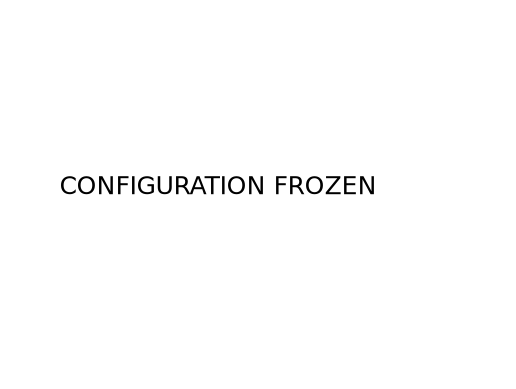

In [38]:
FROZEN={"augmentation":AUGMENTATION,"hog":{**SELECTED_HOG,"pixels_per_cell":list(SELECTED_HOG["pixels_per_cell"]),"cells_per_block":list(SELECTED_HOG["cells_per_block"])},"logistic":{"C":SELECTED_C,"solver":"lbfgs","max_iter":500},"selection":{"clean_tolerance":CLEAN_TOLERANCE,"robust_score":"min(clean,shift,rotation,scale)"}}; print(FROZEN); plt.axis("off"); plt.text(.1,.5,"CONFIGURATION FROZEN",fontsize=18); plt.show()

## 8.2 — Full Development Training

**What:** Augment full 49k, HOG, fit scaler/final_model.

**Why:** Tận dụng Train+Validation sau freeze.

**How:** Không đọc Test.

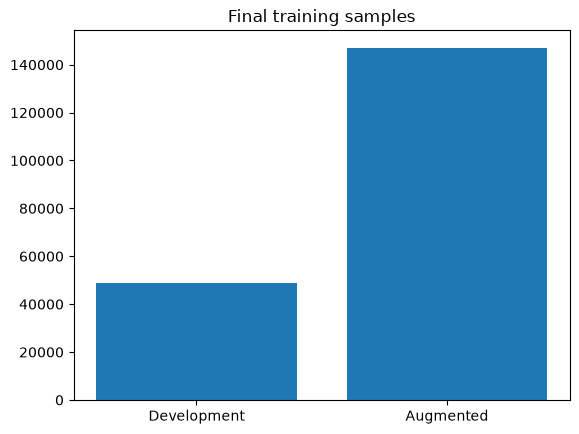

In [39]:
X_full_aug,y_full_aug=augment_training(np.asarray(X_all),y_all,AUGMENTATION); X_full_hog=extract_hog(X_full_aug,SELECTED_HOG); final_scaler=StandardScaler(); X_full_hog_s=final_scaler.fit_transform(X_full_hog); final_model=LogisticRegression(C=SELECTED_C,solver="lbfgs",max_iter=500).fit(X_full_hog_s,y_full_aug)  # USER-RUN FINAL TRAINING
plt.bar(["Development","Augmented"],[len(X_all),len(X_full_aug)]); plt.title("Final training samples"); plt.show()

## 8.3 — Open Locked Test

**What:** Mở Test sau freeze/final fit.

**Why:** Giữ lifecycle auditable.

**How:** Call duy nhất của load_locked_test().

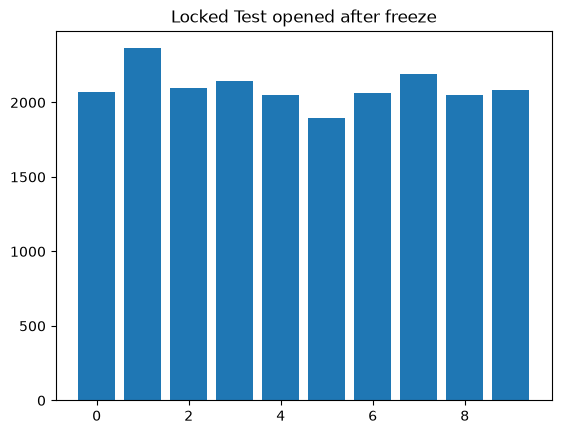

In [40]:
X_test_locked,y_test_locked=load_locked_test(); assert X_test_locked.shape==(21000,784); plt.bar(range(10),np.bincount(y_test_locked)); plt.title("Locked Test opened after freeze"); plt.show()

## 8.4 — Clean Test Evaluation

**What:** Đo Accuracy/Macro F1/report/confusion.

**Why:** Final clean evidence, không dùng tune.

**How:** Frozen HOG/scaler/model only.

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2071
           1       0.99      0.98      0.98      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.98      2142
           4       0.97      0.98      0.97      2047
           5       0.98      0.99      0.98      1894
           6       0.98      0.98      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.97      0.97      0.97      2087

    accuracy                           0.98     21000
   macro avg       0.98      0.98      0.98     21000
weighted avg       0.98      0.98      0.98     21000



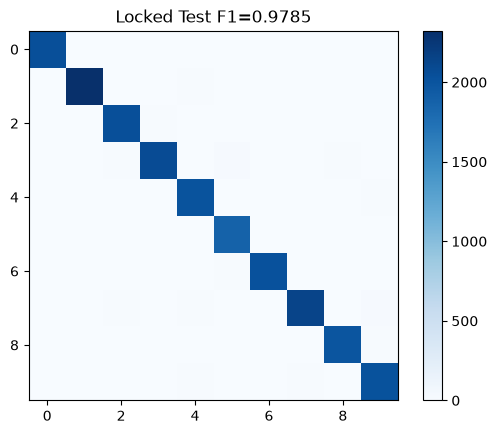

In [41]:
test_pred=predict_hog(final_model,final_scaler,X_test_locked,SELECTED_HOG); TEST_CLEAN={"accuracy":accuracy_score(y_test_locked,test_pred),"macro_f1":f1_score(y_test_locked,test_pred,average="macro")}; test_report=classification_report(y_test_locked,test_pred,output_dict=True); print(classification_report(y_test_locked,test_pred)); plt.imshow(confusion_matrix(y_test_locked,test_pred),cmap="Blues"); plt.colorbar(); plt.title(f"Locked Test F1={TEST_CLEAN['macro_f1']:.4f}"); plt.show()

## 8.5 — Locked-Test Robustness

**What:** Đo frozen transforms trên Test.

**Why:** Final evidence, tuyệt đối không retune.

**How:** Shift ±1/2/3, rotation ±5/10, scale .85/1.15.

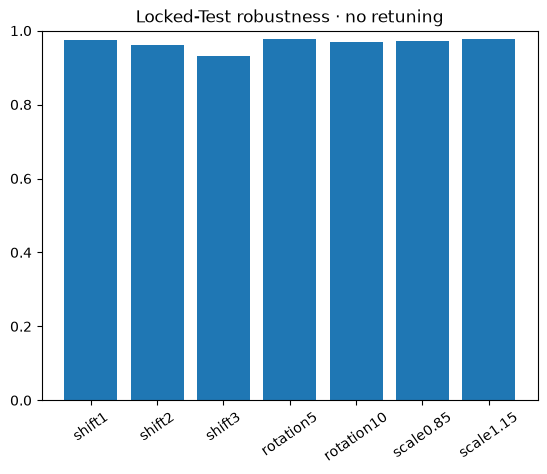

In [42]:
TEST_ROBUST={}
for s in [1,2,3]: TEST_ROBUST[f"shift{s}"]=np.mean([f1_score(y_test_locked,predict_hog(final_model,final_scaler,shift_images(X_test_locked,dx,dy),SELECTED_HOG),average="macro") for dx,dy in [(s,0),(-s,0),(0,s),(0,-s)]])
for a in [5,10]: TEST_ROBUST[f"rotation{a}"]=np.mean([f1_score(y_test_locked,predict_hog(final_model,final_scaler,rotate_images(X_test_locked,d),SELECTED_HOG),average="macro") for d in [-a,a]])
for s in [.85,1.15]: TEST_ROBUST[f"scale{s}"]=f1_score(y_test_locked,predict_hog(final_model,final_scaler,scale_images(X_test_locked,s),SELECTED_HOG),average="macro")
plt.bar(list(TEST_ROBUST),list(TEST_ROBUST.values())); plt.xticks(rotation=35); plt.ylim(0,1); plt.title("Locked-Test robustness · no retuning"); plt.show()

## 8.6 — Final Generalization Summary

**What:** So Validation và Test final evidence.

**Why:** Tổng kết lifecycle bằng một bảng metric.

**How:** Clean, shift2/3, rotation10, scale.85, F1 1/7/9.

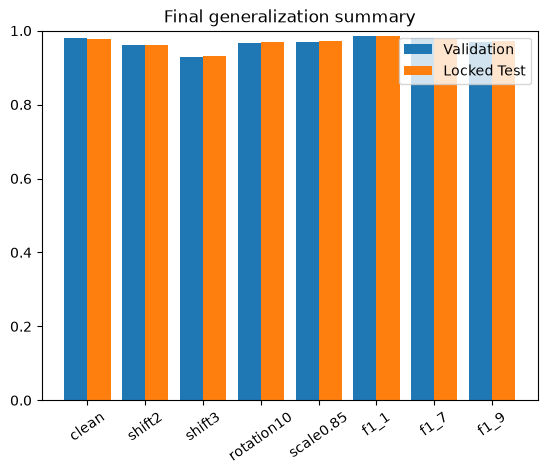

In [43]:
summary_keys=["clean","shift2","shift3","rotation10","scale0.85","f1_1","f1_7","f1_9"]; val_summary=[selected_clean["macro_f1"],selected_robust["shift2"],selected_robust["shift3"],selected_robust["rotation10"],selected_robust["scale0.85"],*[selected_report[str(d)]["f1-score"] for d in focus]]; test_summary=[TEST_CLEAN["macro_f1"],TEST_ROBUST["shift2"],TEST_ROBUST["shift3"],TEST_ROBUST["rotation10"],TEST_ROBUST["scale0.85"],*[test_report[str(d)]["f1-score"] for d in focus]]; x=np.arange(len(summary_keys)); plt.bar(x-.2,val_summary,.4,label="Validation"); plt.bar(x+.2,test_summary,.4,label="Locked Test"); plt.xticks(x,summary_keys,rotation=35); plt.ylim(0,1); plt.legend(); plt.title("Final generalization summary"); plt.show()

## 9.1 — External Input Contract

**What:** Định nghĩa accepted input/output.

**Why:** Deployment preprocessing phải explicit.

**How:** Gray/RGB/RGBA → float32 28×28 [0,1], dark background/light digit.

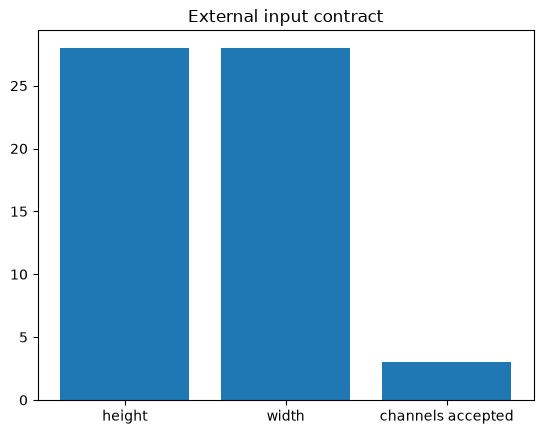

In [44]:
INPUT_CONTRACT={"accepted":["grayscale","RGB","RGBA"],"output_shape":[28,28],"dtype":"float32","range":[0,1],"foreground":"light","background":"dark","preserve_aspect_ratio":True,"square_pad":True}; plt.bar(["height","width","channels accepted"],[28,28,3]); plt.title("External input contract"); plt.show()

## 9.2 — RGBA Handling

**What:** Alpha composite RGBA trước grayscale.

**Why:** Bỏ alpha trực tiếp làm sai transparent canvas.

**How:** Composite lên dark background để giữ model polarity.

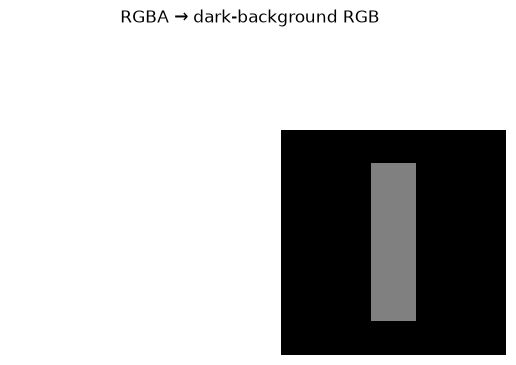

In [45]:
def composite_rgba(image):
 x=np.asarray(image)
 if x.ndim==3 and x.shape[2]==4:
  rgba=x.astype(np.float32)/(255 if x.max()>1 else 1); return rgba[...,:3]*rgba[...,3:4]
 return x
rgba=np.zeros((20,20,4),np.uint8); rgba[3:17,8:12,:3]=255; rgba[3:17,8:12,3]=128; composed=composite_rgba(rgba); fig,ax=plt.subplots(1,2); ax[0].imshow(rgba); ax[1].imshow(composed); [a.axis("off") for a in ax]; plt.suptitle("RGBA → dark-background RGB"); plt.show()

## 9.3 — Foreground Polarity

**What:** Normalize external polarity.

**Why:** Model expects dark background/light digit.

**How:** Invert khi border brightness > center brightness.

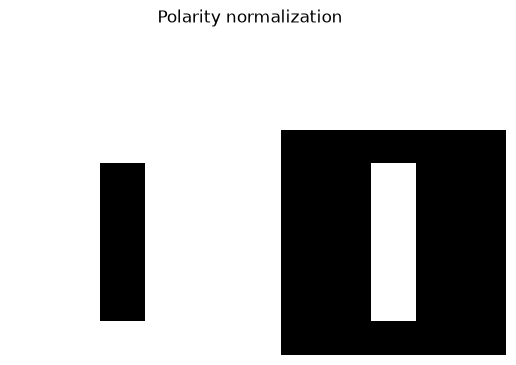

In [46]:
def to_gray(image):
 x=np.asarray(composite_rgba(image));
 if x.ndim==2:return x.astype(np.float32)
 if x.ndim==3 and x.shape[2]>=3:return (x[...,:3]@np.array([.299,.587,.114])).astype(np.float32)
 raise ValueError(f"Unsupported shape {x.shape}")
def normalize_polarity(image):
 x=to_gray(image); x=x/(255 if x.max()>1 else 1); x=np.clip(x,0,1); border=np.concatenate([x[0],x[-1],x[:,0],x[:,-1]]); return 1-x if border.mean()>.5 else x
white=np.ones((20,20),np.float32); white[3:17,8:12]=0; fixed=normalize_polarity(white); fig,ax=plt.subplots(1,2); ax[0].imshow(white,cmap="gray"); ax[1].imshow(fixed,cmap="gray"); [a.axis("off") for a in ax]; plt.suptitle("Polarity normalization"); plt.show()

## 9.4 — Aspect-Ratio Preserving Resize

**What:** Square-pad rồi resize 28×28.

**Why:** Không méo rectangular canvas.

**How:** Không force-center foreground; chỉ pad geometry.

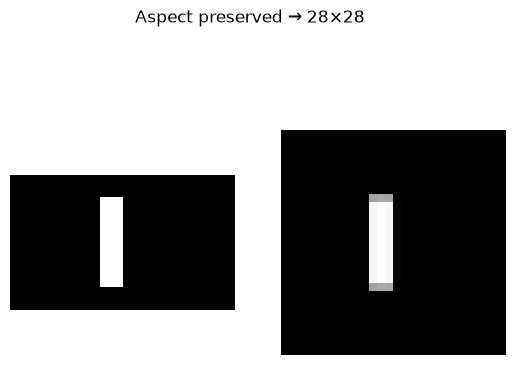

In [47]:
def prepare_input(image):
 x=normalize_polarity(image); h,w=x.shape; side=max(h,w); square=np.zeros((side,side),np.float32); top=(side-h)//2; left=(side-w)//2; square[top:top+h,left:left+w]=x; return resize(np.array(square,copy=True,order="C"),(28,28),preserve_range=True,anti_aliasing=True).astype(np.float32)
rect=np.zeros((30,50),np.float32); rect[5:25,20:25]=1; ready=prepare_input(rect); fig,ax=plt.subplots(1,2); ax[0].imshow(rect,cmap="gray"); ax[1].imshow(ready,cmap="gray"); [a.axis("off") for a in ax]; plt.suptitle("Aspect preserved → 28×28"); plt.show()

## 9.5 — predict_digit()

**What:** Cung cấp một inference function canonical.

**Why:** Ngăn preprocessing drift giữa callers.

**How:** prepare → HOG → scaler → predict_proba.

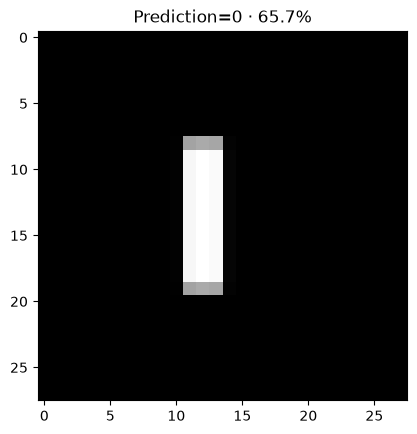

In [48]:
def predict_digit(image):
 prepared=prepare_input(image); features=extract_hog(prepared.reshape(1,-1),SELECTED_HOG); probabilities=final_model.predict_proba(final_scaler.transform(features))[0]; i=int(probabilities.argmax()); return {"prediction":int(final_model.classes_[i]),"confidence":float(probabilities[i]),"probabilities":probabilities,"model_input":prepared}
demo=predict_digit(rect); plt.imshow(demo["model_input"],cmap="gray",vmin=0,vmax=1); plt.title(f"Prediction={demo['prediction']} · {demo['confidence']:.1%}"); plt.show()

## 9.6 — User Handwriting Test

**What:** Đánh giá optional user_drawings sau Test.

**Why:** External/application validation, không model selection.

**How:** Hiển thị exact model input và confidence.

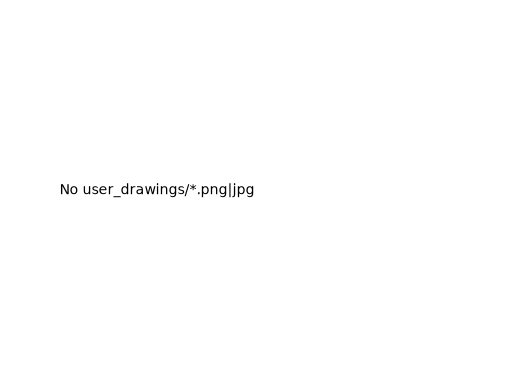

In [49]:
USER_DIR=ROOT/"Model"/"Modeling"/"user_drawings"; user_files=sorted([*USER_DIR.glob("*.png"),*USER_DIR.glob("*.jpg")]) if USER_DIR.exists() else []; user_results=[(path,predict_digit(np.asarray(Image.open(path)))) for path in user_files]
if user_results:
 fig,axes=plt.subplots(1,len(user_results),figsize=(2.5*len(user_results),2.5)); axes=np.atleast_1d(axes)
 for a,(path,r) in zip(axes,user_results): a.imshow(r["model_input"],cmap="gray",vmin=0,vmax=1); a.set_title(f"{path.stem}: {r['prediction']} ({r['confidence']:.1%})"); a.axis("off")
else: plt.axis("off"); plt.text(.1,.5,"No user_drawings/*.png|jpg")
plt.show()

## 9.7 — Package Final Model

**What:** Lưu một atomic HOG package khác raw package.

**Why:** Deployment đủ model/scaler/config/contracts/metrics.

**How:** Temp + read-back + os.replace.

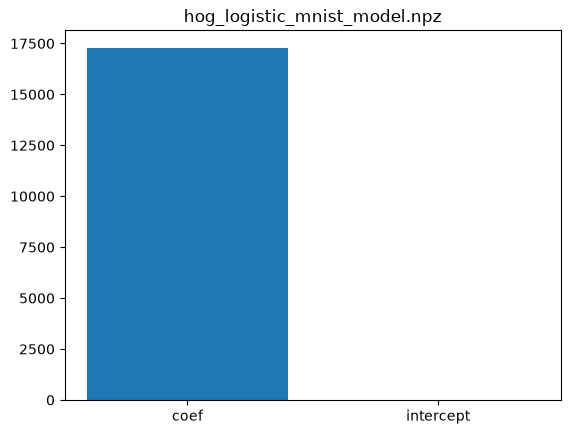

In [50]:
ARTIFACT_DIR=ROOT/"Model"/"Modeling"/"artifacts"; ARTIFACT_DIR.mkdir(parents=True,exist_ok=True); PACKAGE=ARTIFACT_DIR/"hog_logistic_mnist_model.npz"; TMP=ARTIFACT_DIR/"hog_logistic_mnist_model.tmp.npz"; metrics={"validation":dict(zip(summary_keys,val_summary)),"locked_test":dict(zip(summary_keys,test_summary))}
if TMP.exists(): TMP.unlink()
np.savez_compressed(TMP,coef=final_model.coef_.astype(np.float32),intercept=final_model.intercept_.astype(np.float32),classes=final_model.classes_,scaler_mean=final_scaler.mean_.astype(np.float32),scaler_scale=final_scaler.scale_.astype(np.float32),config_json=np.array(json.dumps(FROZEN)),input_contract_json=np.array(json.dumps(INPUT_CONTRACT)),metrics_json=np.array(json.dumps(metrics)))
with np.load(TMP,allow_pickle=False) as z: assert z["coef"].shape[0]==10 and json.loads(z["input_contract_json"].item())["output_shape"]==[28,28]
os.replace(TMP,PACKAGE); plt.bar(["coef","intercept"],[final_model.coef_.size,final_model.intercept_.size]); plt.title(PACKAGE.name); plt.show()